In [2]:
# Phase-5 Strategic RiskOps Intelligence Layer

In [3]:
# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load Required Datasets

In [6]:
transactions = pd.read_csv("transactions_clean.csv")

alerts = pd.read_csv("alerts_table.csv")

investigations = pd.read_csv("investigations_table.csv")

alerts_investigations = alerts.merge(
    investigations,
    on="Alert_ID",
    how="left"
)

print(alerts_investigations.shape)

(1728, 12)


In [7]:
# MODULE 1 — False Positive Cost Optimization

In [8]:
# Calculate False Positive Cost
INVESTIGATION_COST = 15
CHURN_COST = 200

false_positives = (
    alerts_investigations["Outcome"] == "False Positive"
).sum()

false_positive_cost = false_positives * (
    INVESTIGATION_COST + CHURN_COST
)

print("False Positive Cost:", false_positive_cost)

False Positive Cost: 155445


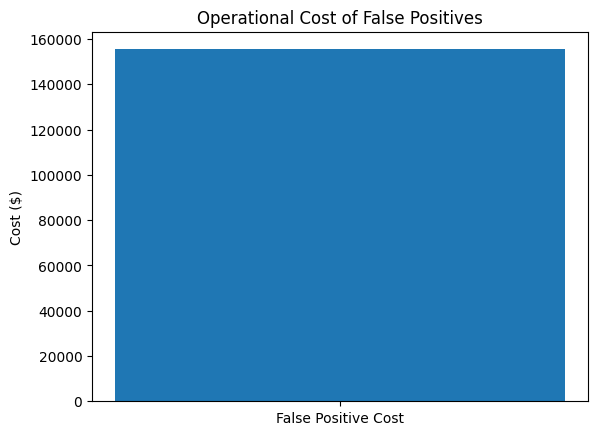

In [9]:
labels = ["False Positive Cost"]
values = [false_positive_cost]

plt.bar(labels, values)

plt.title("Operational Cost of False Positives")

plt.ylabel("Cost ($)")

plt.show()

In [10]:
# MODULE 2 — Risk Threshold Simulation

In [11]:
fraud_cases = (
    alerts_investigations["Outcome"] == "Fraud"
).sum()

total_alerts = len(alerts_investigations)

simulation_results = []

for reduction in [0.1,0.2,0.3]:

    new_alerts = int(total_alerts * (1-reduction))

    fraud_detected = int(fraud_cases * (1-reduction))

    investigation_cost = new_alerts * 15

    fraud_loss = fraud_detected * 500

    net_value = fraud_loss - investigation_cost

    simulation_results.append([
        reduction,
        new_alerts,
        fraud_detected,
        net_value
    ])

In [12]:
threshold_simulation = pd.DataFrame(
    simulation_results,
    columns=[
        "Alert Reduction %",
        "New Alert Volume",
        "Fraud Detected",
        "Net Value"
    ]
)

print(threshold_simulation)

   Alert Reduction %  New Alert Volume  Fraud Detected  Net Value
0                0.1              1555             904     428675
1                0.2              1382             804     381270
2                0.3              1209             703     333365


In [13]:
# MODULE 3 — Fraud Loss Pareto Analysis

In [14]:
# Fraud Loss Calculation
fraud_transactions = alerts_investigations[
    alerts_investigations["Outcome"] == "Fraud"
]

fraud_transactions["Fraud_Loss"] = 500

/tmp/ipykernel_520/440717008.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_transactions["Fraud_Loss"] = 500


In [15]:
# Pareto Aggregation
fraud_loss_pareto = fraud_transactions.groupby(
    "Risk_Tier"
)["Fraud_Loss"].sum().sort_values(
    ascending=False
)

print(fraud_loss_pareto)

Risk_Tier
Medium    492500
High       10000
Name: Fraud_Loss, dtype: int64


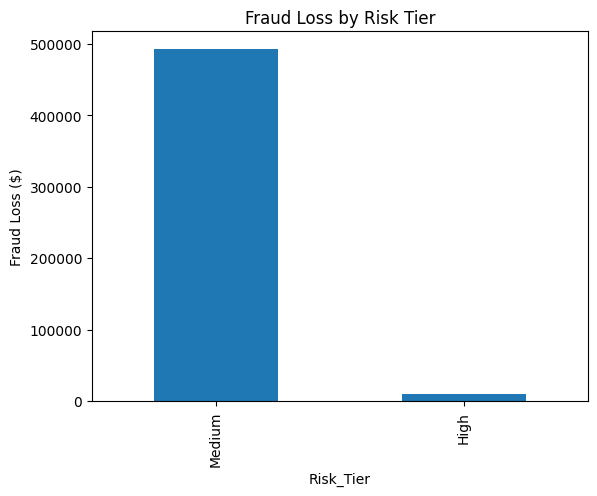

In [16]:
# Pareto Chart
fraud_loss_pareto.plot(
    kind="bar",
    title="Fraud Loss by Risk Tier"
)

plt.ylabel("Fraud Loss ($)")

plt.show()

In [17]:
# MODULE 4 — Investigator Productivity Analysis

In [18]:
# Case Volume per Investigator
investigator_productivity = investigations.groupby(
    "Investigator_ID"
).agg({

"Alert_ID":"count",
"Resolution_Time_Minutes":"mean"

}).rename(columns={
"Alert_ID":"Cases_Handled",
"Resolution_Time_Minutes":"Avg_Investigation_Time"
})

In [19]:
# Rank Investigators
investigator_productivity = investigator_productivity.sort_values(
    by="Cases_Handled",
    ascending=False
)

print(investigator_productivity.head())

                 Cases_Handled  Avg_Investigation_Time
Investigator_ID                                       
INV_9                      409               91.026895
INV_20                     400               92.135000
INV_24                     389               96.069409
INV_6                      382               93.505236
INV_11                     382               93.767016


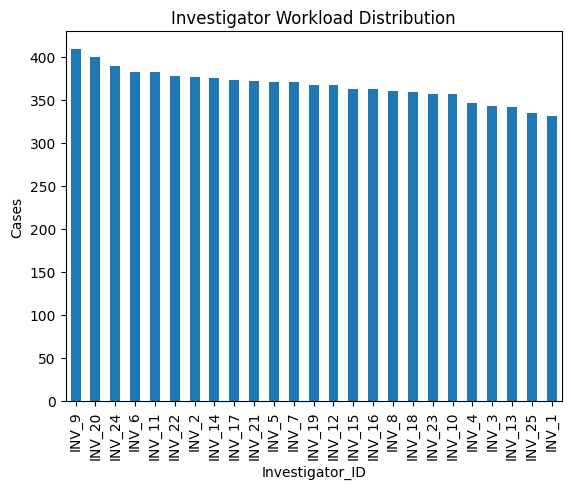

In [20]:
# Productivity Visualization
investigator_productivity["Cases_Handled"].plot(
    kind="bar",
    title="Investigator Workload Distribution"
)

plt.ylabel("Cases")

plt.show()

In [21]:
# MODULE 5 — Executive Decision Table

In [22]:
executive_summary = pd.DataFrame({

"Metric":[
"Total Alerts",
"Fraud Cases Detected",
"False Positives",
"False Positive Cost",
"Net Fraud Prevention Value"
],

"Value":[
total_alerts,
fraud_cases,
false_positives,
false_positive_cost,
fraud_cases*500 - total_alerts*15
]

})

print(executive_summary)

                       Metric   Value
0                Total Alerts    1728
1        Fraud Cases Detected    1005
2             False Positives     723
3         False Positive Cost  155445
4  Net Fraud Prevention Value  476580


In [23]:
# Alert Funnel Analysis

Fraud Operations Funnel
Transactions
↓
Alerts Generated
↓
Investigations
↓
Confirmed Fraud
↓
False Positives

In [24]:
total_transactions = len(transactions)

alerts_generated = len(alerts)

investigations_completed = len(investigations)

fraud_detected = (
    alerts_investigations["Outcome"] == "Fraud"
).sum()

false_positives = (
    alerts_investigations["Outcome"] == "False Positive"
).sum()

funnel = pd.DataFrame({

"Stage":[
"Transactions",
"Alerts Generated",
"Investigations",
"Fraud Detected",
"False Positives"
],

"Count":[
total_transactions,
alerts_generated,
investigations_completed,
fraud_detected,
false_positives
]

})

print(funnel)

              Stage    Count
0      Transactions  6362620
1  Alerts Generated     1728
2    Investigations     9167
3    Fraud Detected     1005
4   False Positives      723


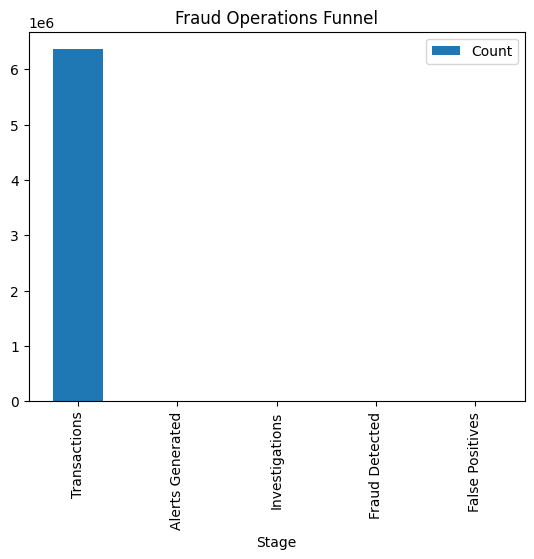

In [25]:
funnel.plot(
    x="Stage",
    y="Count",
    kind="bar",
    title="Fraud Operations Funnel"
)

plt.show()

In [26]:
# Investigator Efficiency Score

In [27]:
investigator_productivity["Efficiency_Score"] = (
    investigator_productivity["Cases_Handled"] /
    investigator_productivity["Avg_Investigation_Time"]
)

top_investigators = investigator_productivity.sort_values(
    by="Efficiency_Score",
    ascending=False
)

print(top_investigators.head())

                 Cases_Handled  Avg_Investigation_Time  Efficiency_Score
Investigator_ID                                                         
INV_9                      409               91.026895          4.493178
INV_20                     400               92.135000          4.341455
INV_2                      376               90.180851          4.169400
INV_6                      382               93.505236          4.085333
INV_17                     373               91.380697          4.081825


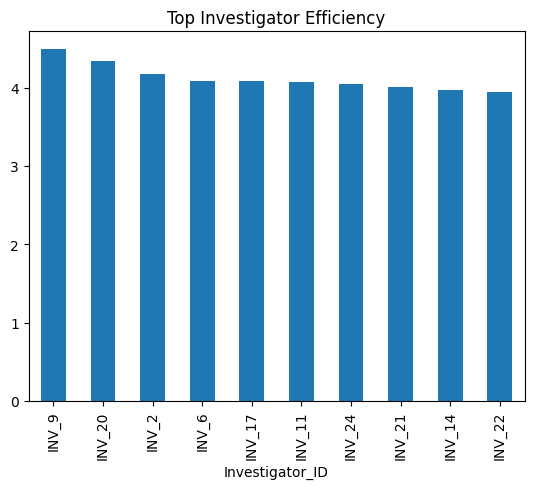

In [28]:
top_investigators["Efficiency_Score"].head(10).plot(
    kind="bar",
    title="Top Investigator Efficiency"
)

plt.show()

In [29]:
# Cost per Fraud Detected

In [32]:
# MODULE 8 — Cost per Fraud Detected

# Define cost parameters
INVESTIGATION_COST = 15
AVG_FRAUD_LOSS = 500

# Total investigation cost
total_investigation_cost = total_alerts * INVESTIGATION_COST

# Cost to detect one fraud case
cost_per_fraud = total_investigation_cost / fraud_cases

print("Total Investigation Cost:", total_investigation_cost)
print("Fraud Cases Detected:", fraud_cases)
print("Cost per Fraud Case:", cost_per_fraud)

Total Investigation Cost: 25920
Fraud Cases Detected: 1005
Cost per Fraud Case: 25.791044776119403


In [33]:
# ROI of Fraud Detection

In [34]:
# ROI Calculation

fraud_loss_prevented = fraud_cases * AVG_FRAUD_LOSS

roi = fraud_loss_prevented / total_investigation_cost

print("Fraud Loss Prevented:", fraud_loss_prevented)
print("ROI of Fraud Detection:", roi)

Fraud Loss Prevented: 502500
ROI of Fraud Detection: 19.386574074074073


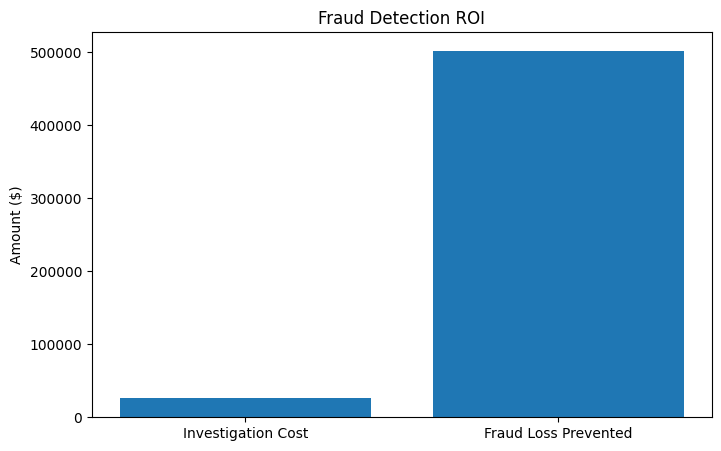

In [35]:
# Visualization

metrics = [
    "Investigation Cost",
    "Fraud Loss Prevented"
]

values = [
    total_investigation_cost,
    fraud_loss_prevented
]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.title("Fraud Detection ROI")

plt.ylabel("Amount ($)")

plt.show()

In [36]:
# Executive Metric Table

In [37]:
# Executive Financial Metrics

financial_metrics = pd.DataFrame({

"Metric":[
"Total Investigation Cost",
"Fraud Loss Prevented",
"Cost per Fraud Case",
"Fraud Detection ROI"
],

"Value":[
total_investigation_cost,
fraud_loss_prevented,
cost_per_fraud,
roi
]

})

print(financial_metrics)

                     Metric          Value
0  Total Investigation Cost   25920.000000
1      Fraud Loss Prevented  502500.000000
2       Cost per Fraud Case      25.791045
3       Fraud Detection ROI      19.386574
